# Pre-class Assignment 6

**Due Sunday night at the start of Week 6**

*See 5/2 announcement on Canvas for details on the deadline.*

#### ✅ Owen Sliger

---

## Terms in a Fourier series

We've started exploring Fourier series. Let's think about how to apply this tool to a function defined over time, f(t).

In PCA 5, we saw that we can write any function $f(\theta)$ as a Fourier series sum:

$$f(\theta) = \sum_{n=-\infty}^{\infty} c_n e^{in\theta}$$

The coefficients $c_n$ are defined as:

$$c_n = \frac{1}{2\pi}\int_0^{2\pi} e^{-i n \theta} f(\theta) \text{d}\theta$$

We can translate our main variable to $t$ instead of $\theta$, to match a function defined over time. This also means the upper limit of the $c_n$ integral turns into our time-period $T$, and $\text{d}\theta$ turns into $\frac{2\pi}{T}\text{d}t$. This gives: 

$$f(t) = \sum_{n=-\infty}^{\infty} c_n e^{i n t}$$

and

$$c_n = \frac{1}{T}\int_0^{T} e^{-i n t} f(t) \text{d}t$$

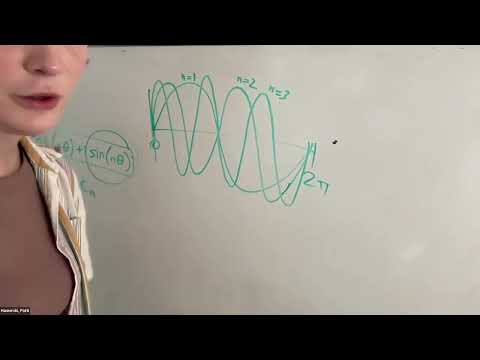

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("QCL9n1Ome5E", width=600, height=350)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_byk2yfo4

**&#9989; Do this:** In your own words, how does $c_{50}$ relate to frequency in a given Fourier series?

$c_{50}$ corresponds to the amplitude that describes how much of a wave at frequency n=50 influences a sum of waves over n.

---

## Computing many Fourier series terms

**&#9989; Do this:** You'll find `birds-mono.wav` the `hub_data_share/data/` directory. Read the file into this notebook, and play the audio out loud.

*Hint: Some relevant functions were mentioned in ICA 5.2.*

In [2]:
from scipy.io import wavfile
from IPython.display import Audio

bird_rate, bird_data = wavfile.read('/home/hub_data_share/data/birds-mono.wav')
bird = Audio(bird_data,rate = bird_rate)

display(bird)

**&#9989; Do this:** Compute the total period (in seconds) of the audio file.

In [3]:
N = bird_data.size
period = N/bird_rate
print(f'The period of the audio file is {period:.2f} seconds')

The period of the audio file is 1.62 seconds


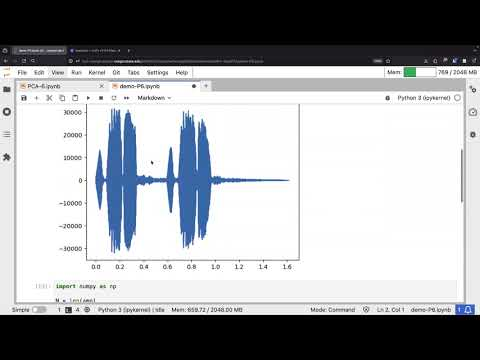

In [4]:
from IPython.display import YouTubeVideo
YouTubeVideo("ed-1fLPZ12M", width=600, height=350)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_pwio3t7x

**&#9989; Do this:** Calculate $c_1$ for bird chirping audio data.

*Hint: use scipy.integrate.trapezoid.*

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
from scipy import integrate

time = np.linspace(0,period,N)
n = 1

cn = (1/period)*(scipy.integrate.trapezoid(np.exp(-1j*n*time)*bird_data,x=time))
                                     
print(cn)

(-0.10198038917707872+0.001874277145804524j)


**&#9989; Do this:** Compute the first 5,000 values of $c_n$ for bird audio data, and time how long it takes. A stopwatch is okay, you don't need to be exact.

In [12]:
%%time
c = np.zeros(N,dtype='complex')
ticks = 5000
tick_arr = np.linspace(0,ticks)

for n in range(ticks):
    integral = scipy.integrate.trapezoid(np.exp(-1j*n*time)*bird_data,x=time)
    c[n] = (1/period)*integral

CPU times: user 27.7 s, sys: 8.48 s, total: 36.2 s
Wall time: 37.5 s


**&#9989; Do this:** How long did it take? How long do you estimate it would take to compute all 70,000+ terms in the series?

The code took 37.5 seconds to run. Assuming adding n values increases the amount of time it takes to run linearly, the entire file would take around 525 seconds, or 8 minutes and 45 seconds.

---

## Fast Fourier Transforms

We need a faster way to comput $c_n$ terms! We use something called a "Discrete Fourier transform." A more complete [derivation can be found here](https://github.com/hamerski/PH-36X-Public/blob/main/Fourier.md), but the basic setup is described below.

The Discrete Fourier Transform simplifies units dramatically. It takes time and frequency and reduces them to integers, $n$ and $k$. This strips the units out of time and frequency, and sets each step in time to 1 "time-unit" and each step in frequency to 1 "frequency-unit." This also sets the total time period equal to the total number of data points, so $T=N$. 

The **Discrete Fourier Transform** is written as $X(k)$, and the corresponding **Inverse Discrete Fourier Transform** is written as a small $x(n)$.

$$X(k) = \sum_{n=0}^{N-1} e^{-i 2\pi kn/N} x(n)$$

$$x(n) = \frac{1}{N} \sum_{k = 0}^{N-1} X(k) e^{i 2\pi kn/N}$$

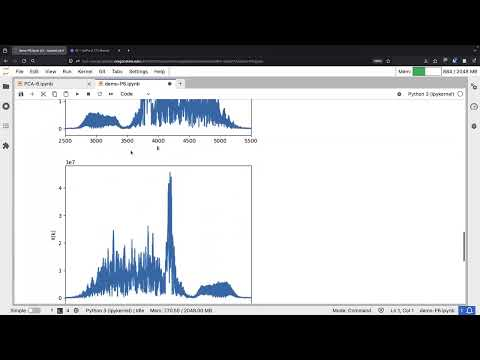

In [13]:
from IPython.display import YouTubeVideo
YouTubeVideo("iEbGJLZdZNo", width=600, height=350)

If the YouTube video didn't load, you can access a MediaSpace version here: 
https://media.oregonstate.edu/media/t/1_78j9yoja

**&#9989; Do this:** Compute the Discrete Fourier Transform ($X(k)$) of the bird audio data, using a Fast Fourier Transform.

In [14]:
cn_bird = scipy.fft.fft(bird_data)

**&#9989; Do this:** Plot $X(k)$ for the bird data.

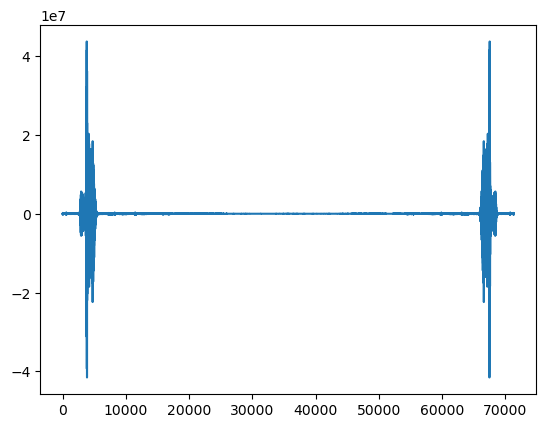

In [16]:
plt.plot(cn_bird);

**&#9989; Do this:** Plot $X(k)$, but scale the frequency to Hz.

*Hint: How is frequency defined in the Discrete Fourier Transform?*

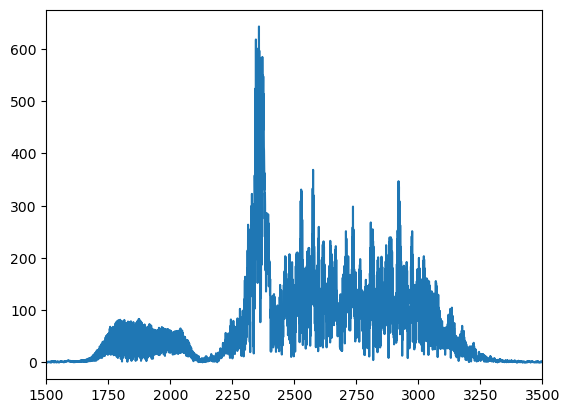

In [17]:
N_arr = np.arange(0,bird_data.size)

plt.plot(N_arr/period,np.real(abs(cn_bird))/bird_data.size);
plt.axis(xmax=3500, xmin=1500);

### That's all! You've reached the end of the pre-class assignment.

Scroll through to make sure you didn't miss any tasks (marked with &#x2705;). Download your work as an HTML file, by selecting: `File` --> `Save and Export Notebook As...` --> `HTML` inside the JupyterHub interface (don't select your browser's File menu). 

Open your downloaded file to ensure the contents look okay, then submit it on Canvas.